### Dependency import

In [15]:
import os
import torch
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from os2d.modeling.model import build_os2d_from_config
from os2d.config import cfg
from os2d.utils import read_image
from PIL import Image
import scipy.stats as stats


### 設定設備

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔹 使用設備：{device}")

🔹 使用設備：cuda


### 載入模型

In [3]:
def load_os2d_model():
    """ 載入 OS2D 模型 """
    cfg.init.model = "models/os2d_v2-train.pth"  # 你的 OS2D 權重檔案
    cfg.is_cuda = torch.cuda.is_available()

    model_output = build_os2d_from_config(cfg)
    if model_output is None:
        raise RuntimeError("❌ 無法載入 OS2D 模型，請檢查權重檔案是否存在。")

    net, _, _, _, _ = model_output
    net.eval()  # 設定為推論模式
    return net

### 讀取並預處理影像

In [4]:
def preprocess_image(image_path):
    """ 讀取影像並轉換為 PyTorch Tensor，確保格式正確 """
    image = Image.open(image_path).convert("RGB")  # 轉換為 RGB 格式
    image_np = np.array(image, dtype=np.float32)  # 轉換為 NumPy 陣列 (H, W, C)
    
    # 轉換為 PyTorch Tensor，並改變維度順序
    image_th = torch.tensor(image_np).permute(2, 0, 1).unsqueeze(0) / 255.0  # (H, W, C) -> (1, C, H, W)
    return image_th.to(device) 

### 提取影像的特徵圖

In [5]:
def extract_feature_maps(net, input_image_th, class_images_th):
    with torch.no_grad():
        feature_map = net.net_feature_maps(input_image_th)  # 提取輸入影像特徵

        # **修正 class_images_th 維度**
        if isinstance(class_images_th, list):
            class_images_th = torch.stack(class_images_th).to(device)  # 轉換為 GPU 張量
        
        if class_images_th.dim() == 5:  # 如果 shape = [1, 1, C, H, W]，則 squeeze(0)
            class_images_th = class_images_th.squeeze(0)

        # 確保通道數符合 Conv2D 的輸入要求
        assert class_images_th.dim() == 4, f"❌ class_images_th 維度錯誤: {class_images_th.shape}"

        class_feature_maps = net.net_label_features(class_images_th)  # 提取類別影像特徵
        class_feature_maps = torch.stack(class_feature_maps).to(device)  # **確保 class_feature_maps 是 Tensor**
        
        class_head = net.os2d_head_creator.create_os2d_head(class_feature_maps)  # 建立 Head
        loc_pred, class_pred, _, fm_size, _ = net(class_head=class_head, feature_maps=feature_map)  # 物件偵測
    
    return feature_map, class_feature_maps, loc_pred, class_pred, fm_size

### 儲存 256 個特徵通道（PNG & `.npy`）

In [6]:
def save_feature_maps(feature_map, output_dir="feature_maps"):
    os.makedirs(output_dir, exist_ok=True)
    feature_map_np = feature_map.cpu().numpy()[0]  # 移除 batch 維度 (1, 256, H, W) -> (256, H, W)

    for i in range(feature_map_np.shape[0]):
        feature = feature_map_np[i]
        if feature.max() != feature.min():
            feature = (feature - feature.min()) / (feature.max() - feature.min())  # 正規化
            feature = (feature * 255).astype(np.uint8)
        else:
            feature = np.zeros_like(feature, dtype=np.uint8)

        cv2.imwrite(f"{output_dir}/feature_{i}.png", feature)  # 存 PNG
        np.save(f"{output_dir}/feature_{i}.npy", feature)  # 存 .npy

    print(f"✅ 256 個特徵圖已儲存到 `{output_dir}`")

### 產生數據表（CSV）

In [7]:
def generate_feature_table(feature_map, output_csv="feature_statistics.csv"):
    feature_map_np = feature_map.cpu().numpy()[0]
    feature_means = feature_map_np.mean(axis=(1, 2))  # 計算均值
    feature_vars = feature_map_np.var(axis=(1, 2))  # 計算變異數

    df = pd.DataFrame({"Channel Index": np.arange(len(feature_means)), 
                       "Mean Activation": feature_means, 
                       "Variance": feature_vars})
    df_sorted = df.sort_values(by="Mean Activation", ascending=False)
    df_sorted.to_csv(output_csv, index=False)
    print(f"📊 特徵數據表已存為 `{output_csv}`")
    return df_sorted

### 繪製統計圖 (PNG)

In [8]:
def plot_feature_statistics(df_sorted, output_png="feature_statistics.png"):
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")
    plt.xticks(rotation=90)
    plt.title("Top 20 Most Active Feature Channels")
    plt.xlabel("Feature Channel Index")
    plt.ylabel("Mean Activation")
    plt.savefig(output_png)
    print(f"📈 統計圖已儲存為 `{output_png}`")
    plt.show()


### 驗證特徵通道的重要性

In [32]:
def validate_feature_importance(feature_map):
    """ 驗證 OS2D 特徵通道的重要性，並進行統計分析 """
    feature_map_np = feature_map.cpu().numpy()[0]  # shape: (256, H, W)
    
    # 計算不同通道的重要性指標
    feature_means = feature_map_np.mean(axis=(1, 2))  # 均值
    feature_vars = feature_map_np.var(axis=(1, 2))  # 變異數
    feature_stds = np.sqrt(feature_vars)  # 標準差
    feature_max = feature_map_np.max(axis=(1, 2))  # 最大值
    feature_min = feature_map_np.min(axis=(1, 2))  # 最小值
    feature_contrast = (feature_max - feature_min) / (feature_max + feature_min + 1e-8)  # 避免除以 0

    # 生成 DataFrame
    df = pd.DataFrame({
        "Channel Index": np.arange(len(feature_means)), 
        "Mean Activation": feature_means, 
        "Variance": feature_vars,
        "Std Dev": feature_stds,
        "Max Activation": feature_max,
        "Min Activation": feature_min,
        "Contrast": feature_contrast
    })

    # 依據均值活化值排序
    df_sorted = df.sort_values(by="Mean Activation", ascending=False)
    print("✅ 特徵通道驗證完成，結果如下：")
    print(df_sorted.head(10))

    # 使用 t 檢定比較 **高活性通道 vs. 低活性通道**
    high_activity = df_sorted.head(20)["Mean Activation"].values
    low_activity = df_sorted.tail(20)["Mean Activation"].values
    t_stat, p_value = stats.ttest_ind(high_activity, low_activity)

    print(f"📊 t 檢定結果：t = {t_stat:.3f}, p-value = {p_value:.3f}")
    if p_value < 0.05:
        print("✅ 結論：高活性通道與低活性通道有顯著差異")
    else:
        print("❌ 結論：高活性通道與低活性通道沒有顯著差異")

    return df_sorted

### Load Model

In [9]:
net = load_os2d_model()

c:\Users\marti\Desktop\ntut-project\os2d\os2d\os2d\modeling\model.py:306: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


### 影像讀取

In [28]:
input_image = "bedroom"
class_image = "teddy_bear"
input_image_path = "data/testing_input_image/" + input_image + ".jpg" # 替換為你的影像路徑
class_image_path = "data/testing_class_image/" + class_image + ".jpg"
input_image_th = preprocess_image(input_image_path)
class_image_th = preprocess_image(class_image_path).unsqueeze(0)

### 提取特徵圖

In [29]:
feature_map, class_feature_maps, loc_pred, class_pred, fm_size = extract_feature_maps(
    net, input_image_th, class_image_th
)

save_feature_maps(feature_map)

✅ 256 個特徵圖已儲存到 `feature_maps`


### 產生數據圖表跟資料

📊 特徵數據表已存為 `./MyResearch/data_with_csv/bedroomteddy_bear.csv`


C:\Users\marti\AppData\Local\Temp\ipykernel_9488\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/bedroomteddy_bear.png`


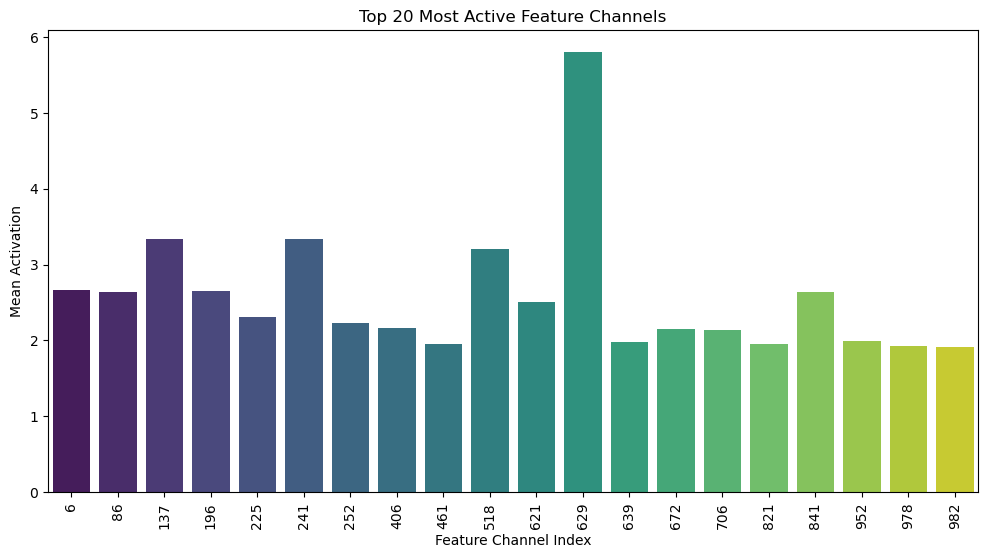

In [30]:
df_sorted = generate_feature_table(feature_map , output_csv= f"./MyResearch/data_with_csv/{input_image + class_image}.csv")

# ✅ 繪製統計圖
plot_feature_statistics(df_sorted , output_png=f"./MyResearch/data_with_png/{input_image +  class_image}.png")


### 驗證特徵通道的重要性

In [31]:
df_sorted = validate_feature_importance(feature_map)

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629            629         5.799875  3.776090  1.943216       10.965744   
241            241         3.336268  3.504616  1.872062       11.580547   
137            137         3.332642  5.788268  2.405882       12.254266   
518            518         3.203773  5.747982  2.397495       14.134734   
6                6         2.663891  0.420496  0.648456        4.910457   
196            196         2.650549  4.244949  2.060328       10.308459   
86              86         2.641335  3.830235  1.957099       11.226843   
841            841         2.635940  4.361179  2.088344        8.831627   
621            621         2.500193  5.185989  2.277277       10.465516   
225            225         2.304896  4.829598  2.197635       12.348708   

     Min Activation  Contrast  
629        0.000000  1.000000  
241        0.000000  1.000000  
137        0.000000  1.000000  
518        0.000000  1.000000

### Test 影像讀取 實驗 4

In [ ]:
image_list = [
    [ "airport" , "airplane" ],
    [ "bedroom" , "teddy_bear" ]
]

# for idx, value in test.items():
#     print( idx )
#     print( value )
### Lab 4 進行通道分析實驗 產生數據

airport
airplane
bedroom
teddy_bear


In [ ]:
for input_image, class_image in image_list :
    input_image_path = "data/demo/" + input_image + ".jpg" # 替換為你的影像路徑
    class_image_path = "data/demo/" + class_image + ".jpg"
    input_image_th = preprocess_image(input_image_path)
    class_image_th = preprocess_image(class_image_path).unsqueeze(0)